# Dyna-Q Agent Training Notebook

This notebook trains a **Dyna-Q** (model-based) reinforcement learning agent on a randomly selected Micromouse maze.

Dyna-Q integrates Q-learning with a planning component that simulates experiences from an internal model.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.dpi'] = 100

from mazemind.envs.maze_parser import parse_maze_file, list_maze_files, load_random_maze, ACTION_DELTAS
from mazemind.envs.micromouse_env import MicromouseEnv
from mazemind.agents.dyna_q import DynaQAgent
from mazemind.training.orchestrator import train_with_snapshots, extract_optimal_path
from mazemind.visualization.maze_renderer import render_maze
from mazemind.visualization.heatmap import render_heatmap, render_q_value_map

print('All imports successful.')

All imports successful.


## 1. Load a Random Maze

Loaded maze: 13ye
Start: (0, 0), Goals: {(8, 7), (8, 8), (7, 7), (7, 8)}
Size: 16x16


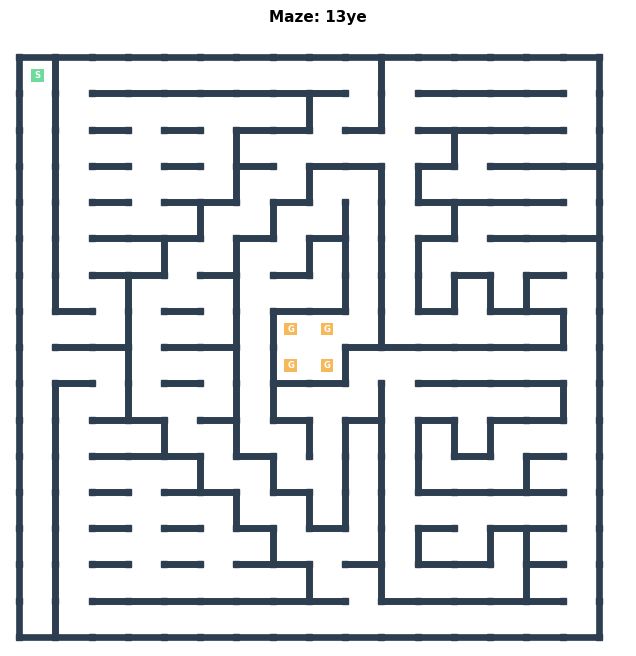

In [2]:
maze_dir = os.path.join('data', 'mazes', 'classic')

# Download mazes if not present
files = list_maze_files(maze_dir)
if len(files) < 3:
    from mazemind.envs.maze_parser import download_mazes
    download_mazes(maze_dir)
    files = list_maze_files(maze_dir)

maze = load_random_maze(maze_dir)
print(f'Loaded maze: {maze.name}')
print(f'Start: {maze.start}, Goals: {maze.goals}')
print(f'Size: {maze.size}x{maze.size}')

fig, ax = render_maze(maze, title=f'Maze: {maze.name}')
plt.show()

## 2. Configure and Train Dyna-Q Agent

In [3]:
alpha = 0.1
gamma = 0.99
epsilon_start = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01
n_planning_steps = 10
n_episodes = 500
max_steps = 1000
seed = 42

agent = DynaQAgent(
    n_planning_steps=n_planning_steps,
    epsilon=epsilon_start,
    epsilon_min=epsilon_min,
    epsilon_decay=epsilon_decay,
)
env = MicromouseEnv(maze)

metrics, snapshots, all_traj, exploration = train_with_snapshots(
    agent, env, n_episodes=n_episodes, max_steps=max_steps,
    alpha=alpha, gamma=gamma, seed=seed,
    snapshot_episodes=[0, 1, 5, 10, 25, 50, 100, 200, 499],
    agent_name='Dyna-Q', maze_name=maze.name,
)

summary = metrics.summary()
for k, v in summary.items():
    print(f'{k}: {v}')

agent: Dyna-Q
maze: 13ye
total_episodes: 500
mean_reward: -103.438
std_reward: 269.9730248673004
mean_steps: 197.368
total_successes: 465
success_rate: 0.93
episodes_to_convergence: 83
total_steps_to_convergence: 54110


## 3. Learning Curves

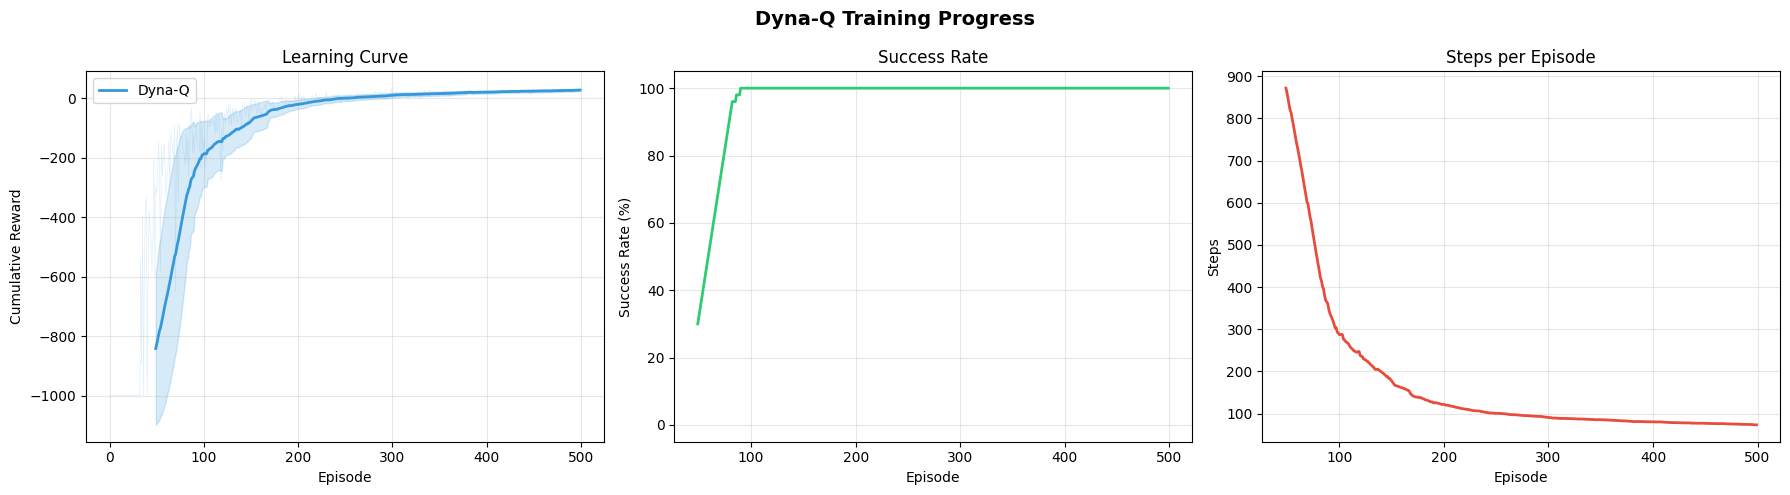

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Reward curve
window = 50
episodes = np.arange(n_episodes)
axes[0].plot(episodes, metrics.rewards, alpha=0.15, color='#3498db', linewidth=0.5)
smoothed = metrics.avg_reward(window)
axes[0].plot(episodes[window-1:], smoothed, color='#3498db', linewidth=2, label='Dyna-Q')
axes[0].fill_between(
    episodes[window-1:],
    smoothed - np.array([metrics.rewards[max(0,i-window+1):i+1].std() for i in range(window-1, n_episodes)]),
    smoothed + np.array([metrics.rewards[max(0,i-window+1):i+1].std() for i in range(window-1, n_episodes)]),
    alpha=0.2, color='#3498db'
)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Cumulative Reward')
axes[0].set_title('Learning Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Success rate
sr = metrics.success_rate(window)
axes[1].plot(episodes[window-1:], sr * 100, color='#2ecc71', linewidth=2)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Success Rate (%)')
axes[1].set_title('Success Rate')
axes[1].set_ylim(-5, 105)
axes[1].grid(True, alpha=0.3)

# Steps per episode
steps_smooth = np.convolve(metrics.steps, np.ones(window)/window, mode='valid')
axes[2].plot(episodes[window-1:], steps_smooth, color='#e74c3c', linewidth=2)
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Steps')
axes[2].set_title('Steps per Episode')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Dyna-Q Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Optimal Path Discovery

Optimal path length: 68 steps
Path: [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (8, 1)]...


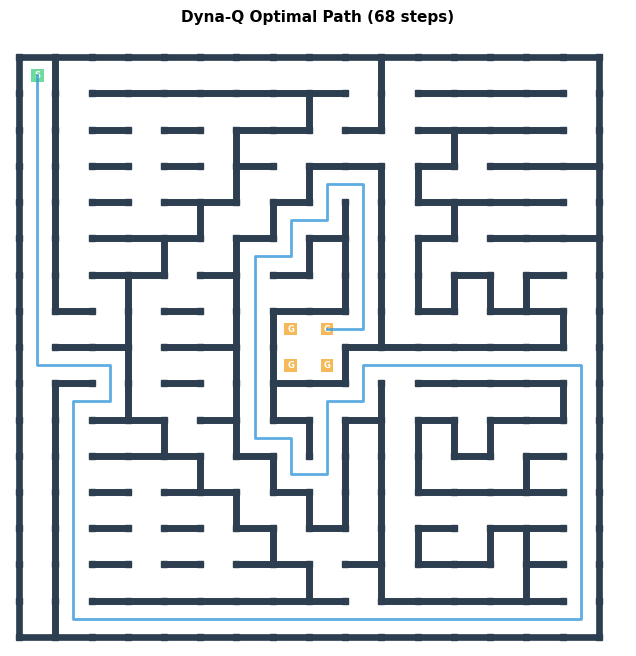

In [5]:
path = extract_optimal_path(agent, MicromouseEnv(maze))
print(f'Optimal path length: {len(path)} steps')
print(f'Path: {path[:10]}...')

fig, ax = render_maze(maze, title=f'Dyna-Q Optimal Path ({len(path)} steps)', path=path)
plt.show()

## 5. State Visitation Heatmap

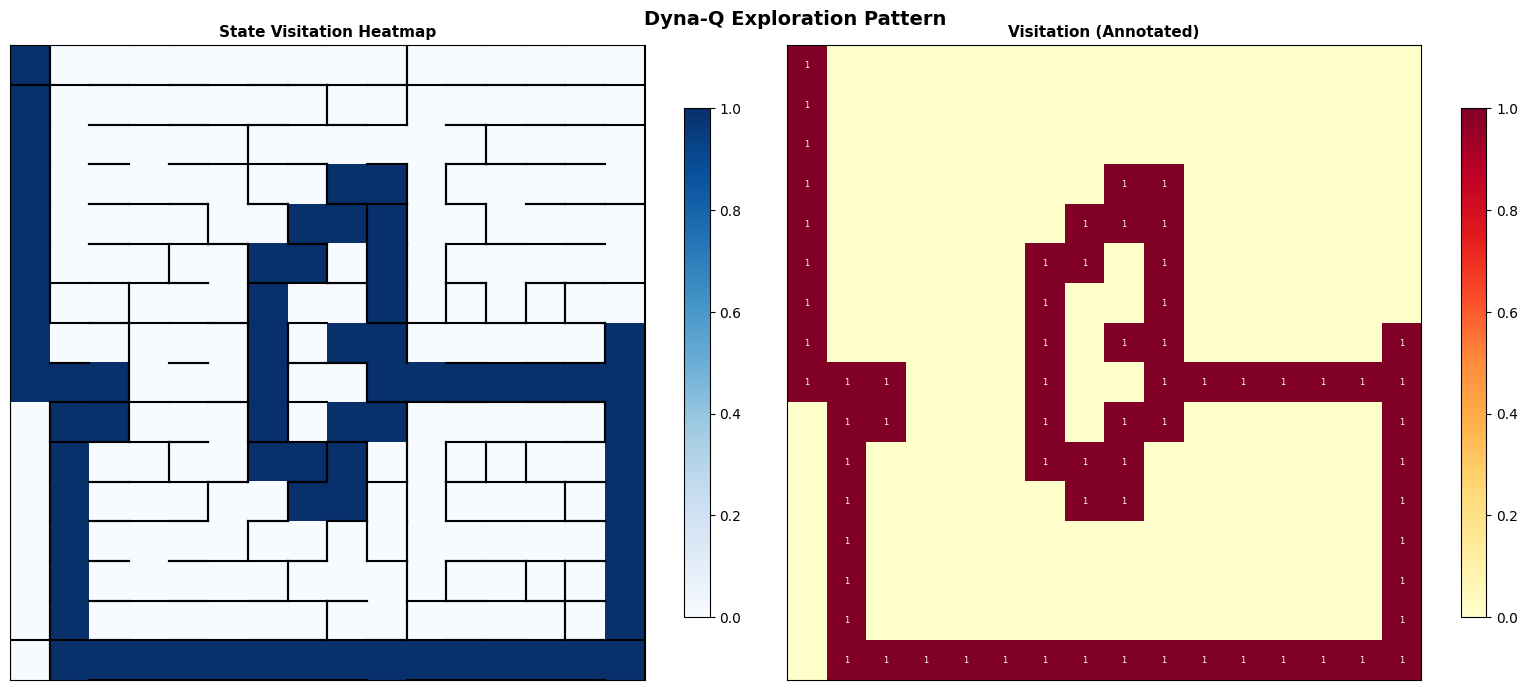

In [6]:
visit_counts = env.get_visit_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

render_heatmap(visit_counts, ax=axes[0], title='State Visitation Heatmap', cmap='Blues', maze=maze)
render_heatmap(visit_counts, ax=axes[1], title='Visitation (Annotated)', cmap='YlOrRd', annotate=True)

plt.suptitle('Dyna-Q Exploration Pattern', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Q-Value Visualization

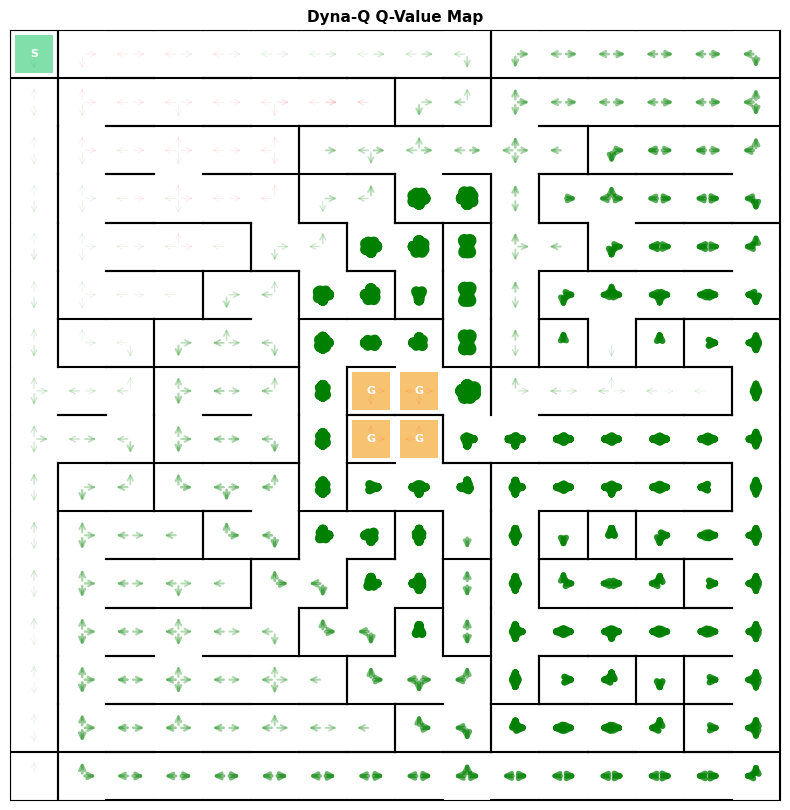

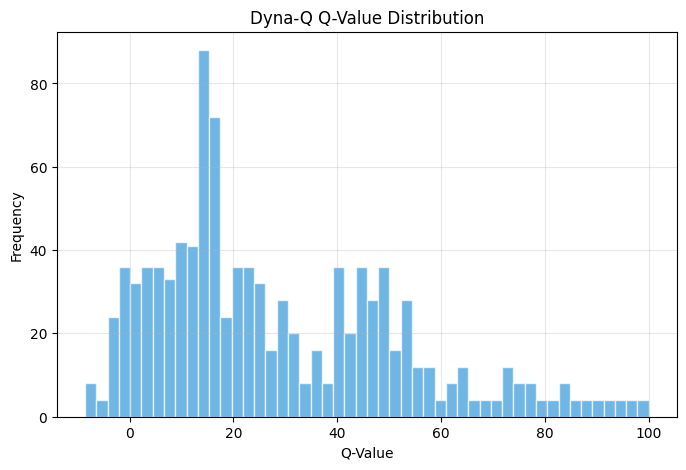

Q-table stats: min=-8.5777, max=100.0000, mean_nonzero=28.3790


In [7]:
fig, ax = render_q_value_map(agent.q_table, maze, title='Dyna-Q Q-Value Map')
plt.show()

# Q-value distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
q_vals = agent.q_table[agent.q_table != 0].flatten()
if len(q_vals) > 0:
    ax.hist(q_vals, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
ax.set_xlabel('Q-Value')
ax.set_ylabel('Frequency')
ax.set_title('Dyna-Q Q-Value Distribution')
ax.grid(True, alpha=0.3)
plt.show()

print(f'Q-table stats: min={agent.q_table.min():.4f}, max={agent.q_table.max():.4f}, '
      f'mean_nonzero={q_vals.mean() if len(q_vals)>0 else 0:.4f}')

## 7. Dynamic Visualization: Episode Replay

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

if len(path) > 1:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))

    def animate(frame):
        ax.clear()
        render_maze(maze, ax=ax, title=f'Dyna-Q Path Replay (step {frame+1}/{len(path)})',
                   path=path[:frame+1], agent_pos=path[frame])

    anim = FuncAnimation(fig, animate, frames=len(path), interval=200, repeat=True) 
    plt.close()
    display(HTML(anim.to_jshtml()))
else:
    print('Path too short for animation.')